In [19]:
import json
import numpy as np
from mapelite.config import PRECOMPILED_EMBEDDINGS_PATH
_dataset_path = PRECOMPILED_EMBEDDINGS_PATH
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]

NS_PATH = "data/ns/"

ns_elites_path = NS_PATH + "elites.json"

with open(ns_elites_path, "r") as f:
    elites_data = json.load(f)

# print the outline of the JSON structure
metadata = elites_data["metadata"]
elites = elites_data["elites"]
print("Number of elites:", len(elites))
print("Elite keys:", elites[0].keys())

Number of elites: 661
Elite keys: dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells', 'trackSize', 'fitness', 'embedding', 'archiveIndex'])


Speed metric has 0 zeros out of 4979417 values.
Steering metric has 2376 zeros out of 4979417 values.
Distance from side metric has 0 zeros out of 4979417 values.
[ 6.48648e+01  1.33923e-02  1.36024e+01  6.44346e+01  1.25898e-02
  1.45230e+01  6.12907e+01  1.66727e-02  1.52328e+01  5.88738e+01
  1.16239e-02  1.57138e+01  5.63204e+01  9.90176e-03  1.59846e+01
  5.33297e+01  2.91854e-02  1.58849e+01  5.05997e+01  6.01993e-02
  1.50476e+01  4.80661e+01  7.13042e-02  1.38793e+01  4.53817e+01
  5.94559e-02  1.27933e+01  4.22669e+01  1.02398e-01  1.19783e+01
  3.93941e+01  1.36476e-01  1.08838e+01  3.67537e+01  9.13402e-02
  9.36253e+00  3.41676e+01  4.60505e-02  7.55041e+00  3.17199e+01
  5.13559e-02  5.56259e+00  2.98514e+01  8.20393e-02  3.61915e+00
  2.78984e+01  1.40707e-01  2.07293e+00  2.66778e+01  1.34022e-01
  1.39994e+00  2.57959e+01  1.36723e-01  1.25452e+00  2.48884e+01
  1.44432e-01  1.26951e+00  2.43360e+01  1.48668e-01  1.29597e+00
  2.38404e+01  1.63736e-01  1.28703e+00  2.31

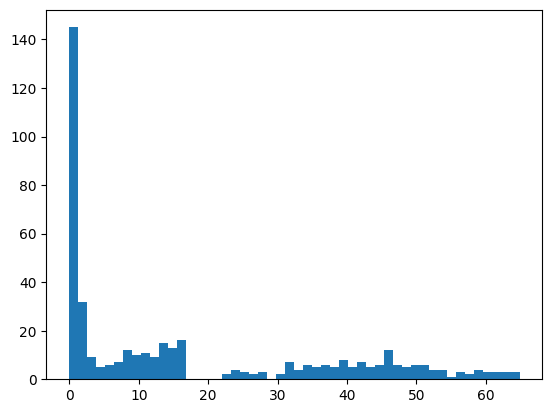

In [20]:
# load dataset at : mapelite\embeddings\datasets\dataset20k_metrics_mixedRng_tita.npz
import matplotlib.pyplot as plt

dataset = np.load("mapelite/embeddings/datasets/dataset20k_metrics_mixedRng_tita.npz")
flat_metrics = dataset["data"]
indices = dataset["indices"]
ids = dataset["ids"]

flat_metrics = np.delete(flat_metrics, [0,3,4,5], axis=1)

# get separate metrics based on indices in order speed steering dist_from_side
speed_metrics = flat_metrics[:, 0]
steering_metrics = flat_metrics[:, 1]
dist_from_side_metrics = flat_metrics[:, 2]

# count the 0s in each metric
speed_zero_count = sum(1 for x in speed_metrics if x == 0)
steering_zero_count = sum(1 for x in steering_metrics if x == 0)
dist_from_side_zero_count = sum(1 for x in dist_from_side_metrics if x == 0)

print(f"Speed metric has {speed_zero_count} zeros out of {len(speed_metrics)} values.")
print(f"Steering metric has {steering_zero_count} zeros out of {len(steering_metrics)} values.")
print(f"Distance from side metric has {dist_from_side_zero_count} zeros out of {len(dist_from_side_metrics)} values.")

metrics = np.split(flat_metrics, indices)

# pick a 10 random metrics and print the 0 percentage for each of them
for i in range(1):
    metric = metrics[i]
    flattened_metric = metric.flatten()
    print(flattened_metric)
    #plot number distribution of values in the metric
    plt.hist(flattened_metric, bins=50)
    plt.show()


In [21]:
import sys
from mapelite.qd_runner import QDRunner
import mapelite.emitter as emitter_module
import mapelite.utils as utils_module
import mapelite.config as config_module
from scipy.spatial.distance import pdist, squareform
# Teach pickle that the old top-level 'emitter' is now 'mapelite.emitter'
sys.modules['emitter'] = emitter_module
sys.modules['utils'] = utils_module
sys.modules['config'] = config_module


# load from checkpoint
checkpoint_dir = NS_PATH + "checkpoints/"
state = QDRunner.get_state_from_checkpoint(checkpoint_dir)
stats = state["stats"]

print("stats keys:", stats[0].keys())
grid_state = stats[-1]["grid_state"]
print("grid_state keys:", grid_state[-1].keys())

# sort grid_state by sub_count highest to lowest
grid_state_sorted = sorted(grid_state, key=lambda x: x["sub_count"], reverse=True)

print(grid_state_sorted[0]["elite"].keys())


2026-04-10 18:12:11 [info     ] Checkpoint loaded              path=data/ns/checkpoints\checkpoint_0999.pkl resume_iter=1000
stats keys: dict_keys(['iteration', 'initial_WSS', 'Archive size', 'iteration_best', 'global_best_score', 'global_best_id', 'new_elites', 'substituted_elites', 'wss', 'qd_score', 'acceptance_rate', 'mean_pairwise_dist', 'high_quality_coverage', 'mean_knn_novelty', 'fitness_novelty_corr', 'grid_state'])
grid_state keys: dict_keys(['elite', 'sub_count', 'new', 'fitness'])
dict_keys(['id', 'mode', 'rngMode', 'dataSet', 'selectedCells'])


In [22]:
import umap
import os
import matplotlib.pyplot as plt
import numpy as np
# Cell to calculate and save UMAP model of precomputed embeddings
embeddings_data = _embeddings
print(f"Loaded precomputed embeddings with shape: {embeddings_data.shape}")

# Fit UMAP to the precomputed embeddings
umap_model = umap.UMAP(n_components=2, random_state=67)
umap_model = umap_model.fit(embeddings_data)

#print umap max and min x,y values
umap_embeddings = umap_model.transform(embeddings_data)
print(f"UMAP embeddings x,y borders:")
print(f"x: min={umap_embeddings[:,0].min()}, max={umap_embeddings[:,0].max()}")
print(f"y: min={umap_embeddings[:,1].min()}, max={umap_embeddings[:,1].max()}")


Loaded precomputed embeddings with shape: (19672, 32)


d:\dev\Quality-Diversity-for-Racing-Track-Design\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP embeddings x,y borders:
x: min=-0.16545291244983673, max=8.359619140625
y: min=-3.1245930194854736, max=3.884744167327881


Elite ID 740.9304278588332 UMAP 2D coords: [ 5.9630914  -0.08002346]
Elite ID 530.8986821617839 UMAP 2D coords: [6.978368   0.07923695]
Elite ID 878.8943889450716 UMAP 2D coords: [6.691778  1.1621202]
Elite ID 964.115789443865 UMAP 2D coords: [6.280257   0.15171109]
Elite ID 618.3023691197159 UMAP 2D coords: [6.0523577 1.0097076]


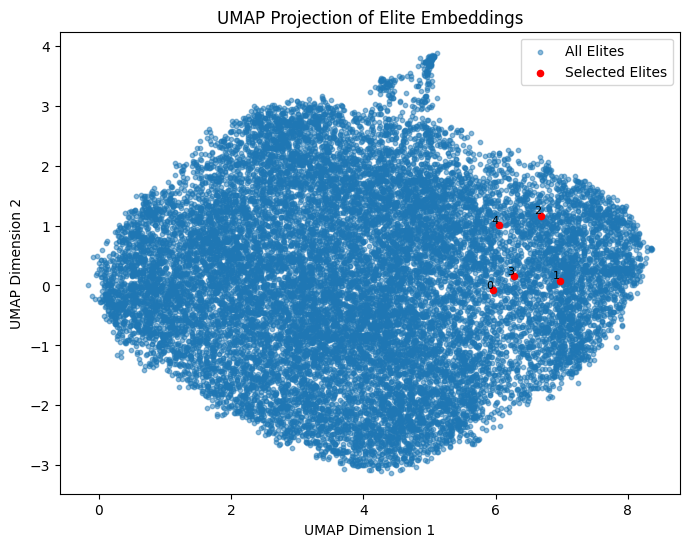

In [23]:
import joblib
import numpy as np
import matplotlib.pyplot as plt
selected_elite_ids = [740.9304278588332, 530.8986821617839, 878.8943889450716, 964.115789443865, 618.3023691197159]


# Preserve order of elite_ids
id_to_elite = {elite["id"]: elite for elite in elites}
selected_elites = [id_to_elite[eid] for eid in selected_elite_ids if eid in id_to_elite]
selected_embeddings = [elite["embedding"] for elite in selected_elites]

reduced_points = []
for elite in selected_elites:
    embedding = elite["embedding"]
    point = umap_model.transform([embedding])[0]
    print(f"Elite ID {elite['id']} UMAP 2D coords: {point}")
    reduced_points.append(point)

# Plot
plt.figure(figsize=(8, 6))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            s=10, alpha=0.5, label="All Elites")

reduced_points = np.array(reduced_points)
plt.scatter(reduced_points[:, 0], reduced_points[:, 1],
            s=20, color="red", label="Selected Elites")

# Add numbering based on order in elite_ids
for i, (x, y) in enumerate(reduced_points):
    plt.text(x, y, str(i), fontsize=8, ha='right', va='bottom', color='black')

plt.title("UMAP Projection of Elite Embeddings")
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.legend()
plt.show()

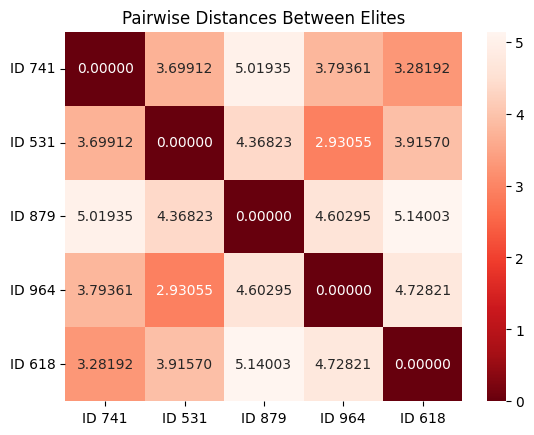

In [24]:
from scipy.spatial.distance import pdist, squareform
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

latent_distance_matrix = squareform(pdist(selected_embeddings, metric="euclidean"))

# shorten labels for readability
labels = [f"ID {id:.0f}" for id in selected_elite_ids]

sns.heatmap(latent_distance_matrix, annot=True, cmap="Reds_r", xticklabels=labels, yticklabels=labels, fmt=".5f")
plt.title("Pairwise Distances Between Elites")
plt.yticks(rotation=0)
plt.show()

Elite ID: 740.9304278588332
Distances: [3.45105386 3.47638878 3.88025157 3.88377577 3.97909556 4.02722381
 4.04409684 4.1095435  4.13260838 4.13718352 4.14440088 4.22040815
 4.2412737  4.25518923 4.25565891 4.25726821 4.26970429 4.28041906
 4.29275609 4.30215462 4.31597718 4.32486189 4.34769659 4.3533134
 4.35781403 4.36230305 4.37286968 4.37371062 4.37905735 4.40283314]
Mean distance to neighbors: 4.17436
---


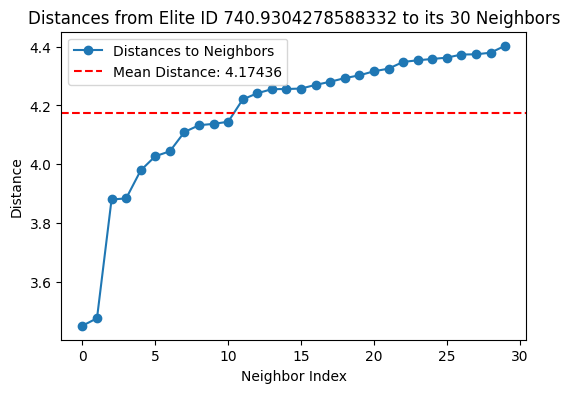

Elite ID: 530.8986821617839
Distances: [3.64036088 3.6909296  3.9029695  3.9639014  4.39706426 4.5761151
 4.63932864 4.65645896 4.67467269 4.68918458 4.73174821 4.84752878
 4.85803863 4.88284501 4.9913257  4.99342553 4.99898271 5.00042518
 5.02471805 5.03517583 5.03979756 5.04220844 5.05903726 5.0882731
 5.10258237 5.12714244 5.12992548 5.15129872 5.1549351  5.16358212]
Mean distance to neighbors: 4.77513
---


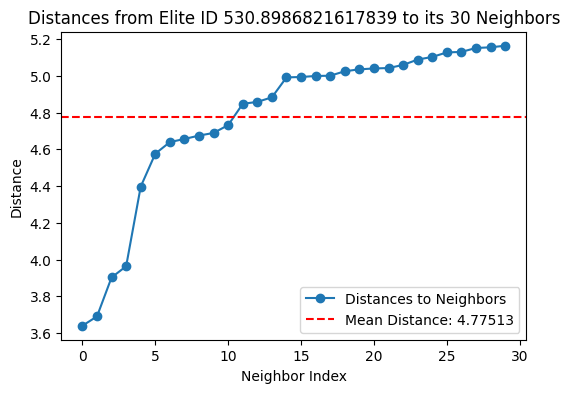

Elite ID: 878.8943889450716
Distances: [3.6653089  3.68493878 3.89618408 3.93427017 4.01904304 4.05551508
 4.14185437 4.1716987  4.18133374 4.19359895 4.22172308 4.24335988
 4.24538898 4.28332167 4.30846255 4.3202803  4.32461052 4.34164272
 4.36022039 4.36238515 4.36820763 4.41338665 4.45128552 4.46253185
 4.49471685 4.51000162 4.51218437 4.53265795 4.53379711 4.55570455]
Mean distance to neighbors: 4.25965
---


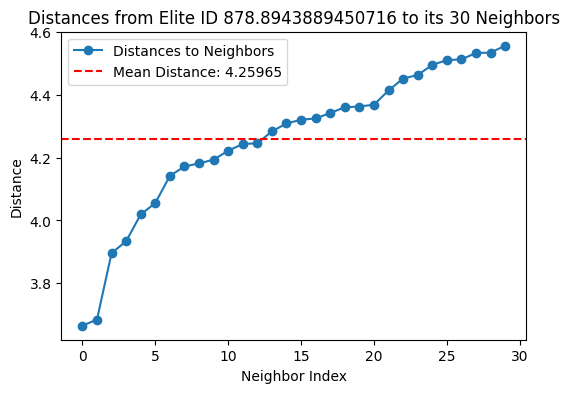

Elite ID: 964.115789443865
Distances: [3.12211606 3.85198433 4.20198133 4.22469792 4.26555532 4.40818747
 4.60204257 4.66305834 4.77719846 4.78001624 4.83665353 4.86924448
 4.87448442 4.93253825 4.94161837 4.96266295 4.9778648  4.98637079
 5.0804898  5.12468185 5.13583513 5.15922406 5.16226097 5.17956716
 5.20961714 5.21913924 5.22977301 5.27844323 5.3096838  5.34185838]
Mean distance to neighbors: 4.82363
---


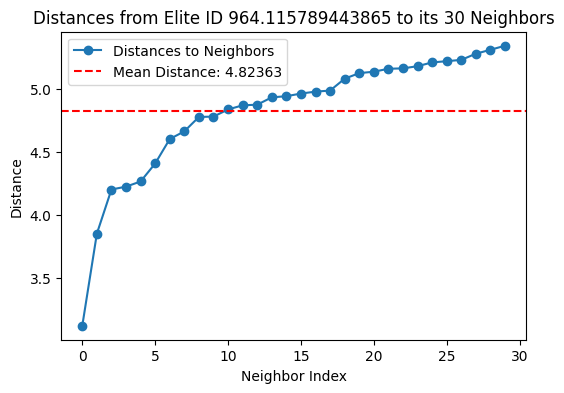

Elite ID: 618.3023691197159
Distances: [3.65663123 3.96143085 3.96588446 4.00913742 4.04782533 4.10181581
 4.14293888 4.27398055 4.38242002 4.41020016 4.42091225 4.45352936
 4.47420974 4.49763527 4.53914891 4.55228324 4.5623273  4.56860464
 4.63364958 4.63441682 4.67155007 4.68037808 4.69141979 4.69773631
 4.73208078 4.7355534  4.74014555 4.74193437 4.75426618 4.80440291]
Mean distance to neighbors: 4.45128
---


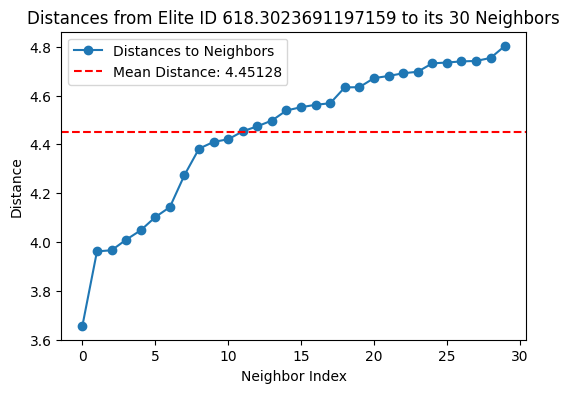

In [25]:
# compute kNeighbors for each elite
from sklearn.neighbors import NearestNeighbors


elites_minus_selected = [elite for elite in elites if elite["id"] not in selected_elite_ids]

elite_embeddings = [elite["embedding"] for elite in elites_minus_selected]

n_neighbors = 30
knn = NearestNeighbors(n_neighbors=n_neighbors)
knn.fit(elite_embeddings)

for i, elite in enumerate(selected_elites):
    elite_id = elite["id"]
    elite_embedding = elite["embedding"]
    distances, indices = knn.kneighbors([elite_embedding])
    mean_distance = np.mean(distances)
    print(f"Elite ID: {elite_id}")
    print(f"Distances: {distances[0]}")
    print(f"Mean distance to neighbors: {mean_distance:.5f}")
    print("---")
    # plot distances and mean distance
    plt.figure(figsize=(6, 4))
    plt.plot(distances[0], marker='o', label='Distances to Neighbors')
    plt.axhline(mean_distance, color='red', linestyle='--', label=f'Mean Distance: {mean_distance:.5f}')
    plt.title(f"Distances from Elite ID {elite_id} to its {n_neighbors} Neighbors")
    plt.xlabel("Neighbor Index")
    plt.ylabel("Distance")
    plt.legend()
    plt.show()
    
    


##### mean neighbor distance for top 5 and bottom 5 elites by sub_count

##### mean distance in embedding space of umap clusters

In [26]:
k = 15
X = np.array(_embeddings)
knn = NearestNeighbors(n_neighbors=k + 1, metric='euclidean')
knn.fit(X)


near_ids = [444.22041405950336, 652.4195413315717, 894.5473669528045]
near_elites = [elite for elite in elites if elite["id"] in near_ids]

sparse_ids = [979.6166047852373,995.6815485034725, 439.2284344674571]
sparse_elites = [elite for elite in elites if elite["id"] in sparse_ids]

near_distances = get_mean_k_distance(knn, near_elites, k)
print("\n--- Near Elites: Mean Neighborhood Distance (k={k}) ---")
for eid, dist in near_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

sparse_distances = get_mean_k_distance(knn, sparse_elites, k)
print("\n--- Sparse Elites: Mean Neighborhood Distance (k={k}) ---")
for eid, dist in sparse_distances:
    print(f"Elite ID {eid}: {dist:.4f}")

maxY = max(max([dist for _, dist in near_distances]), max([dist for _, dist in sparse_distances])) * 1.1

plt.figure(figsize=(6, 3))
plt.bar(x=[str(int(eid)) for eid, _ in near_distances], height=[dist for _, dist in near_distances], color='blue')

plt.bar(x=[str(int(eid)) for eid, _ in sparse_distances], height=[dist for _, dist in sparse_distances], color='red')
plt.title("Near vs Sparse Elites mean neighborhood distance")
plt.ylabel("Mean Distance")
plt.ylim(0, maxY)

# Add legend
plt.legend(["Near Elites", "Sparse Elites"])

plt.show()



NameError: name 'get_mean_k_distance' is not defined